# Donation-Intent Classifier Training — Fine-Tuned Encoder (RoBERTa vs DeBERTa-v3)

This notebook is the **classifier-training** counterpart to the earlier
LLM-as-annotator notebook. Instead of prompting a generative model, it
**fine-tunes a text encoder** (RoBERTa-base and DeBERTa-v3-base, compared
head-to-head) with two output heads:

- a **binary head** for `binary_label` (`yes` / `no`)
- a **three-way head** for `modifier` (`none` / `deferred` / `conditional`)

Both heads sit on the same pooled `[CLS]` representation and are trained
jointly (multi-task loss = binary CE + modifier CE). The `modifier` head is
architecturally secondary to `binary_label` per the task spec (its output is
only meaningful once `binary_label` is decided), but for a clean fixed-shape
model interface **both heads are computed for every example**; the
`modifier` loss/metrics are reported both overall and specifically among
`binary_label == "yes"` rows (the population the task spec conditions on),
so the analysis stays faithful to the "conditioned on `binary_label=yes`"
framing.

**Data.** Full manually-labeled dataset of **1017** conversations
(`conversation_id, dialogue_id, dialogue_text, binary_label, modifier`).
Unlike the earlier 250-row 5-annotator sample, this dataset has **no
partition/annotator column**, so there is no partition-specific
drift check in this run. A blank/NaN `modifier` value is treated as `"none"`.
Input discovery reuses the same fuzzy, case-insensitive filename search as
the earlier notebook, so it picks the CSV up automatically once added as a
Kaggle input — no path edits needed.

**Split.** Stratified **70/15/15** train/validation/test split, stratified by
the joint `binary_label`×`modifier` distribution so all three splits keep a
similar label mix.

**Class imbalance.** Handled two ways simultaneously, per the observed
imbalance (Table II):
1. **Class weights** — inverse-frequency weights fed into both heads' loss
   functions.
2. **Oversampling** — a `WeightedRandomSampler` over the *training* split
   only (val/test stay untouched, so evaluation numbers stay honest) that
   oversamples minority joint-label combinations.

A **majority-class baseline** is reported alongside the trained models for
both heads, as required by the task spec.

**Evaluation.** Accuracy + F1 for the binary head, macro-F1 for the modifier
head, plus the majority-class baseline, for **both encoders**, on the held-out
test split.


## 0b. Install / upgrade dependencies

Installs required packages from PyPI. Running in **online mode** on Kaggle T4.
The `--no-deps` guard on `accelerate` prevents silently downgrading a
GPU-matched `torch` build already present on the Kaggle image.

In [1]:
# =============================================================
# 0b. INSTALL / UPGRADE DEPENDENCIES (online mode)
# =============================================================
import subprocess, sys

subprocess.run([
    sys.executable, "-m", "pip", "install", "-q", "-U",
    "transformers>=4.44.0,<4.47.0", "sentencepiece", "tqdm",
    "seaborn", "scikit-learn",
], check=True)
# --no-deps: keep the GPU-matched torch already on the Kaggle image
subprocess.run([
    sys.executable, "-m", "pip", "install", "-q", "-U",
    "--no-deps", "accelerate>=0.34.0",
], check=True)
print("All required Python packages installed successfully.")


     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.1/44.1 kB 1.5 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 57.3/57.3 kB 4.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.0/10.0 MB 76.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.4/1.4 MB 51.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 80.2/80.2 kB 5.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.1/9.1 MB 93.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 566.4/566.4 kB 32.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.0/3.0 MB 63.5 MB/s eta 0:00:00


ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
dopamine-rl 4.1.2 requires gym<=0.25.2, but you have gym 0.26.2 which is incompatible.
moviepy 1.0.3 requires decorator<5.0,>=4.0.2, but you have decorator 5.3.1 which is incompatible.
sklearn-compat 0.1.5 requires scikit-learn<1.9,>=1.2, but you have scikit-learn 1.9.0 which is incompatible.


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 389.2/389.2 kB 5.7 MB/s eta 0:00:00
All required Python packages installed successfully.


## 1. Imports & global config

In [2]:
# =============================================================
# 1. IMPORTS & GLOBAL CONFIG
# =============================================================
import os, re, json, glob, gc, time, warnings, random
from pathlib import Path
from collections import Counter

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm.auto import tqdm

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader, WeightedRandomSampler

from transformers import AutoTokenizer, AutoModel, get_linear_schedule_with_warmup
from sklearn.model_selection import train_test_split
from sklearn.metrics import (accuracy_score, f1_score, precision_recall_fscore_support,
                              classification_report, confusion_matrix)

warnings.filterwarnings("ignore")
sns.set_theme(style="whitegrid")
pd.set_option("display.max_colwidth", 120)

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
print(f"Using device: {DEVICE}")
print(f"torch version: {torch.__version__} (built for CUDA {torch.version.cuda})")
if DEVICE == "cuda":
    print(f"GPU: {torch.cuda.get_device_name(0)}")

# ---- CONFIG: the only block you should need to touch -----------------
CONFIG = {
    # Same fuzzy recursive search-root convention as the LLM-annotator
    # notebook, so this works unmodified whether the new 1017-row CSV is
    # added as a Kaggle Dataset input or dropped anywhere under these roots.
    "search_roots": ["/kaggle/input", "/kaggle/working", "/workspace", "/data", "."],

    "out_dir": "/kaggle/working" if os.path.isdir("/kaggle/working") else "./outputs",

    # Column-name mapping. If the CSV uses different headers, only this
    # dict needs editing -- nothing downstream references raw column names.
    "column_map": {
        "text": "dialogue_text",
        "binary_label": "binary_label",
        "modifier": "modifier",
        # NOTE: the 1017-row dataset has no annotator/partition column (unlike
        # the earlier 5-annotator CSVs), so there is no partition-drift check
        # in this run -- splitting/stratification below is by label only.
    },

    "binary_classes": ["no", "yes"],
    "modifier_classes": ["none", "deferred", "conditional"],

    # Three encoders benchmarked head-to-head.
    # Per-entry "lr" and "batch_size" override the global defaults;
    # DeBERTa-v3 needs a lower LR (1e-5) and smaller batch (8) for stability.
    "encoders": [
        {"name": "roberta-base",    "hf_id": "roberta-base"},
        {"name": "deberta-v3-base", "hf_id": "microsoft/deberta-v3-base","lr": 5e-6, "batch_size": 8, "warmup_ratio": 0.10},
        {"name": "todbert",         "hf_id": "TODBERT/TOD-BERT-JNT-V1"},
    ],

    "max_length": 256,
    "train_frac": 0.70,
    "val_frac": 0.15,
    "test_frac": 0.15,

    "batch_size": 16,
    "eval_batch_size": 32,
    "num_epochs": 25,
    "lr": 2e-5,
    "weight_decay": 0.01,
    "warmup_ratio": 0.06,
    "max_grad_norm": 1.0,

    # Multi-task loss weighting: binary head is the primary task per the
    # task spec ("conditioned on binary_label=yes"), modifier head is
    # secondary -- weighted down slightly so it doesn't dominate the shared
    # encoder gradient.
    "binary_loss_weight": 1.0,
    "modifier_loss_weight": 0.7,

    # Imbalance handling: inverse-frequency class weights in the loss.
    # Oversampling (WeightedRandomSampler) is DISABLED -- stacking it on
    # top of class weights multiplies their effects and over-rotates the
    # model toward minority classes, collapsing macro-F1 below baseline.
    "use_class_weights": True,
    "use_oversampling": False,

    "early_stopping_patience": 5,   # epochs without val macro-F1 improvement
    "checkpoint_dir_name": "checkpoints",
}

os.makedirs(CONFIG["out_dir"], exist_ok=True)
os.makedirs(os.path.join(CONFIG["out_dir"], CONFIG["checkpoint_dir_name"]), exist_ok=True)
print(json.dumps({k: v for k, v in CONFIG.items() if k != "encoders"}, indent=2))
print("Encoders:", [m["hf_id"] for m in CONFIG["encoders"]])


Using device: cuda
torch version: 2.10.0+cu128 (built for CUDA 12.8)
GPU: Tesla T4
{
  "search_roots": [
    "/kaggle/input",
    "/kaggle/working",
    "/workspace",
    "/data",
    "."
  ],
  "out_dir": "/kaggle/working",
  "column_map": {
    "text": "dialogue_text",
    "binary_label": "binary_label",
    "modifier": "modifier"
  },
  "binary_classes": [
    "no",
    "yes"
  ],
  "modifier_classes": [
    "none",
    "deferred",
    "conditional"
  ],
  "max_length": 256,
  "train_frac": 0.7,
  "val_frac": 0.15,
  "test_frac": 0.15,
  "batch_size": 16,
  "eval_batch_size": 32,
  "num_epochs": 25,
  "lr": 2e-05,
  "weight_decay": 0.01,
  "warmup_ratio": 0.06,
  "max_grad_norm": 1.0,
  "binary_loss_weight": 1.0,
  "modifier_loss_weight": 0.7,
  "use_class_weights": true,
  "use_oversampling": false,
  "early_stopping_patience": 5,
  "checkpoint_dir_name": "checkpoints"
}
Encoders: ['roberta-base', 'microsoft/deberta-v3-base', 'TODBERT/TOD-BERT-JNT-V1']


## 2. Load the labeled dataset

Reuses the earlier notebook's robust, case-insensitive recursive filename
search (handles `Manual_Label__X.csv` vs `Manual Label - X.csv` vs whatever
naming the 1017-row dataset upload ends up with). If more than one matching
CSV is found (e.g. the new dataset is split into parts) they're concatenated;
duplicate `conversation_id`s are dropped, keeping the first occurrence.

In [3]:
# =============================================================
# 2. DATA DISCOVERY & LOADING
# =============================================================

def find_files_ci(roots, must_contain_all, suffix):
    must_contain_all = [t.lower() for t in must_contain_all]
    suffix = suffix.lower()
    found = []
    for root in roots:
        if not os.path.isdir(root):
            continue
        for dirpath, _dirnames, filenames in os.walk(root):
            for fn in filenames:
                low = fn.lower()
                if low.endswith(suffix) and all(tok in low for tok in must_contain_all):
                    found.append(os.path.join(dirpath, fn))
    seen, unique = set(), []
    for f in found:
        if f not in seen:
            seen.add(f)
            unique.append(f)
    return unique

# Broad token so this matches whatever the new 1017-row dataset gets named
# (e.g. "labeled_dataset.csv", "manual_labels_full.csv", ...). Falls back to
# the narrower "manual"+"label" search used by the old notebook if nothing
# broader turns up.
csv_paths = find_files_ci(CONFIG["search_roots"], must_contain_all=["label"], suffix=".csv")
if not csv_paths:
    csv_paths = find_files_ci(CONFIG["search_roots"], must_contain_all=["manual"], suffix=".csv")

print(f"Found {len(csv_paths)} candidate CSV(s):")
for p in csv_paths:
    print(" -", p)

assert len(csv_paths) > 0, (
    "No labeled CSV found under " + str(CONFIG["search_roots"]) +
    ". Make sure the 1017-row dataset has been added as a Kaggle input "
    "(Notebook -> Add Input), or update CONFIG['search_roots']."
)

_dfs = [pd.read_csv(p) for p in csv_paths]
raw_df = pd.concat(_dfs, ignore_index=True) if len(_dfs) > 1 else _dfs[0]

cm = CONFIG["column_map"]
missing_cols = [c for c in cm.values() if c not in raw_df.columns]
assert not missing_cols, (
    f"Expected column(s) {missing_cols} not found in loaded CSV(s). "
    f"Columns present: {list(raw_df.columns)}. "
    "Update CONFIG['column_map'] to match the new dataset's headers."
)

df = raw_df.rename(columns={v: k for k, v in cm.items()})[list(cm.keys())].copy()

# De-dup on the original id column (conversation_id / dialogue_id / id),
# whichever is present, so a re-uploaded or overlapping CSV doesn't double-count rows.
orig_id_col = None
for cand in ["conversation_id", "dialogue_id", "id"]:
    if cand in raw_df.columns:
        orig_id_col = cand
        break
if orig_id_col is not None:
    df["_orig_id"] = raw_df[orig_id_col].values
    before = len(df)
    df = df.drop_duplicates(subset="_orig_id").drop(columns="_orig_id").reset_index(drop=True)
    if len(df) != before:
        print(f"Dropped {before - len(df)} duplicate row(s) by `{orig_id_col}`.")

df["text"] = df["text"].fillna("").astype(str)
df["binary_label"] = df["binary_label"].fillna("").astype(str).str.strip().str.lower()

# Empty/NaN modifier means "none" (confirmed). IMPORTANT: fillna BEFORE
# astype(str) -- pandas' astype(str) does not reliably stringify real NaN
# values on object-dtype columns (they can survive as float NaN), so
# checking for the string "nan" afterward would silently miss them.
df["modifier"] = df["modifier"].fillna("").astype(str).str.strip().str.lower()
df.loc[df["modifier"].isin(["", "nan", "none provided", "na"]), "modifier"] = "none"

bad_binary = ~df["binary_label"].isin(CONFIG["binary_classes"])
bad_modifier = ~df["modifier"].isin(CONFIG["modifier_classes"])
if bad_binary.any() or bad_modifier.any():
    print(f"WARNING: dropping {int((bad_binary | bad_modifier).sum())} row(s) with "
          f"out-of-vocabulary binary_label/modifier values.")
    print("  bad binary_label values:", sorted(df.loc[bad_binary, "binary_label"].unique()))
    print("  bad modifier values:", sorted(df.loc[bad_modifier, "modifier"].unique()))
    df = df.loc[~(bad_binary | bad_modifier)].reset_index(drop=True)

df["binary_id"] = df["binary_label"].map({c: i for i, c in enumerate(CONFIG["binary_classes"])})
df["modifier_id"] = df["modifier"].map({c: i for i, c in enumerate(CONFIG["modifier_classes"])})

print(f"\nLoaded {len(df)} labeled rows after cleaning.")
print("No partition/annotator column in this dataset -- splitting below is by label only.")
df.head()


Found 1 candidate CSV(s):
 - /kaggle/input/datasets/nawrizturjo/persuasion-1/Manual_Label.csv

Loaded 1017 labeled rows after cleaning.
No partition/annotator column in this dataset -- splitting below is by label only.


,text,binary_label,modifier,binary_id,modifier_id
0,"[Persuader] Good morning\n [Persuadee] Good morning \n [Persuader] We are seeking donations for the ""Save the Childr...",yes,none,1,0
1,[Persuader] Could you please donate all of your$2 to Save the Children? Hunger kills millions of children worldwide ...,yes,none,1,0
2,[Persuader] Hello! How are you doing?\n [Persuadee] I am quite good. How about yourself? \n [Persuader] I am doing a...,no,none,0,0
3,"[Persuader] Good evening. How are you doing?\n [Persuadee] I'm doing pretty good, how about yourself?\n [Persuader] ...",yes,none,1,0
4,[Persuader] Hi! How are you today?\n [Persuadee] good :) how are you?\n [Persuader] I'm good. Thanks for asking. Hav...,yes,none,1,0


## 2b. Class distribution & majority-class baseline

Reports the label imbalance (per the task spec: "class imbalance already
observed"), and computes the majority-class baseline accuracy/F1 for both
heads that the trained models are compared against.

binary_label distribution:
binary_label
yes    738
no     279
Name: count, dtype: int64 

modifier distribution:
modifier
none           871
deferred       125
conditional     21
Name: count, dtype: int64 

modifier distribution, restricted to binary_label == 'yes' rows (the population the modifier head is conditioned on):
modifier
none           657
deferred        68
conditional     13
Name: count, dtype: int64


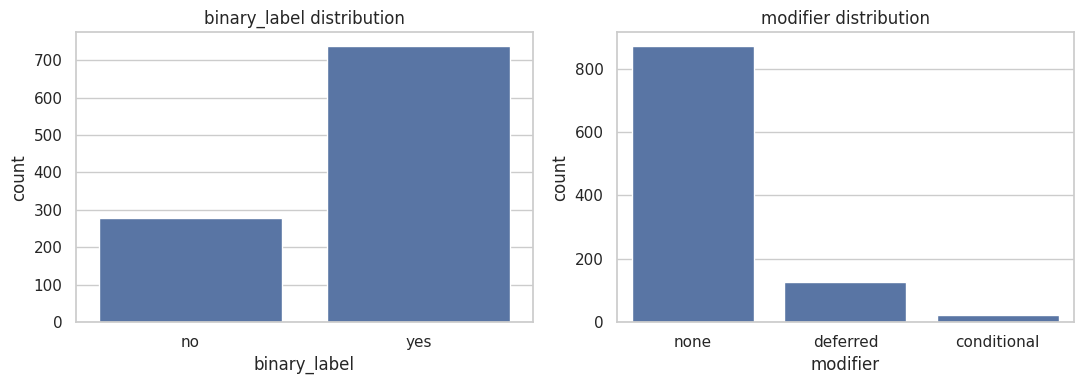


Majority-class baseline (whole dataset, for reference -- the real reported baseline further down uses the TEST split only):
  binary_label: {'majority_class': np.int64(1), 'accuracy': 0.7256637168141593, 'macro_f1': 0.4205128205128205}
  modifier    : {'majority_class': np.int64(0), 'accuracy': 0.856440511307768, 'macro_f1': 0.3075564971751413}


In [4]:
# =============================================================
# 2b. CLASS DISTRIBUTION & MAJORITY-CLASS BASELINE
# =============================================================
print("binary_label distribution:")
print(df["binary_label"].value_counts(), "\n")
print("modifier distribution:")
print(df["modifier"].value_counts(), "\n")
print("modifier distribution, restricted to binary_label == 'yes' rows "
      "(the population the modifier head is conditioned on):")
print(df.loc[df["binary_label"] == "yes", "modifier"].value_counts())

fig, axes = plt.subplots(1, 2, figsize=(11, 4))
sns.countplot(data=df, x="binary_label", order=CONFIG["binary_classes"], ax=axes[0])
axes[0].set_title("binary_label distribution")
sns.countplot(data=df, x="modifier", order=CONFIG["modifier_classes"], ax=axes[1])
axes[1].set_title("modifier distribution")
plt.tight_layout()
plt.savefig(os.path.join(CONFIG["out_dir"], "label_distribution.png"), dpi=150)
plt.show()

def majority_baseline(y_true_ids, n_classes):
    majority_class = Counter(y_true_ids).most_common(1)[0][0]
    y_pred = [majority_class] * len(y_true_ids)
    acc = accuracy_score(y_true_ids, y_pred)
    f1_macro = f1_score(y_true_ids, y_pred, average="macro", labels=list(range(n_classes)), zero_division=0)
    return {"majority_class": majority_class, "accuracy": acc, "macro_f1": f1_macro}

baseline_binary = majority_baseline(df["binary_id"].values, len(CONFIG["binary_classes"]))
baseline_modifier = majority_baseline(df["modifier_id"].values, len(CONFIG["modifier_classes"]))

print("\nMajority-class baseline (whole dataset, for reference -- the real "
      "reported baseline further down uses the TEST split only):")
print("  binary_label:", baseline_binary)
print("  modifier    :", baseline_modifier)


## 3. Stratified 70/15/15 train/val/test split

Stratified by the joint `binary_label`×`modifier` combination, so all three
splits keep a similar label mix (needed for honest evaluation). There is no
partition/annotator column in this 1017-row dataset (unlike the earlier
5-annotator CSVs), so there is no partition-based stratification and no
partition-specific drift check in this run -- if a partition-style column
becomes available later, section 3 and section 11 from the original design
can stratify/report on it directly.


In [5]:
# =============================================================
# 3. STRATIFIED 70/15/15 SPLIT (by binary_label x modifier combination)
# =============================================================

df["_stratum"] = df["binary_label"] + "_" + df["modifier"]

# Collapse strata with <2 members into a single bucket, so stratify= never
# raises on a singleton combination.
strat_counts = df["_stratum"].value_counts()
rare = strat_counts[strat_counts < 2].index
df.loc[df["_stratum"].isin(rare), "_stratum"] = "_singleton_bucket"

train_df, temp_df = train_test_split(
    df, test_size=(CONFIG["val_frac"] + CONFIG["test_frac"]),
    stratify=df["_stratum"], random_state=SEED,
)
# re-derive rare strata on temp_df (some may now be too small) before the 2nd split
temp_counts = temp_df["_stratum"].value_counts()
rare2 = temp_counts[temp_counts < 2].index
temp_df = temp_df.copy()
temp_df.loc[temp_df["_stratum"].isin(rare2), "_stratum"] = "_singleton_bucket"

rel_test_size = CONFIG["test_frac"] / (CONFIG["val_frac"] + CONFIG["test_frac"])
val_df, test_df = train_test_split(
    temp_df, test_size=rel_test_size,
    stratify=temp_df["_stratum"], random_state=SEED,
)

for name, split in [("train", train_df), ("val", val_df), ("test", test_df)]:
    print(f"{name}: n={len(split)} ({len(split)/len(df):.1%})")

print("\nbinary_label composition per split:")
display(pd.concat({
    "train": train_df["binary_label"].value_counts(normalize=True),
    "val": val_df["binary_label"].value_counts(normalize=True),
    "test": test_df["binary_label"].value_counts(normalize=True),
}, axis=1))

print("\nmodifier composition per split:")
display(pd.concat({
    "train": train_df["modifier"].value_counts(normalize=True),
    "val": val_df["modifier"].value_counts(normalize=True),
    "test": test_df["modifier"].value_counts(normalize=True),
}, axis=1))

for split in (train_df, val_df, test_df):
    split.drop(columns=["_stratum"], inplace=True)
train_df = train_df.reset_index(drop=True)
val_df = val_df.reset_index(drop=True)
test_df = test_df.reset_index(drop=True)


train: n=711 (69.9%)
val: n=153 (15.0%)
test: n=153 (15.0%)

binary_label composition per split:


,train,val,test
binary_label,,,
yes,0.724332,0.732026,0.72549
no,0.275668,0.267974,0.27451



modifier composition per split:


,train,val,test
modifier,,,
none,0.856540,0.856209,0.856209
deferred,0.122363,0.124183,0.124183
conditional,0.021097,0.019608,0.019608


## 4. Dataset & tokenization

One `Dataset` class shared across both encoders (only the tokenizer passed in
differs). Tokenization happens lazily per-batch via the `collate_fn` so the
same class works for both encoders without re-instantiating per model.

In [6]:
# =============================================================
# 4. TORCH DATASET
# =============================================================

class DonationIntentDataset(Dataset):
    def __init__(self, dataframe):
        self.texts = dataframe["text"].tolist()
        self.binary_ids = dataframe["binary_id"].tolist()
        self.modifier_ids = dataframe["modifier_id"].tolist()

    def __len__(self):
        return len(self.texts)

    def __getitem__(self, idx):
        return {
            "text": self.texts[idx],
            "binary_id": self.binary_ids[idx],
            "modifier_id": self.modifier_ids[idx],
        }


def make_collate_fn(tokenizer, max_length):
    def collate_fn(batch):
        texts = [b["text"] for b in batch]
        enc = tokenizer(
            texts, padding=True, truncation=True,
            max_length=max_length, return_tensors="pt",
        )
        enc["binary_labels"] = torch.tensor([b["binary_id"] for b in batch], dtype=torch.long)
        enc["modifier_labels"] = torch.tensor([b["modifier_id"] for b in batch], dtype=torch.long)
        return enc
    return collate_fn


def make_oversampling_sampler(dataframe):
    # Oversample by the joint (binary_label, modifier) combination on the
    # TRAINING split only -- inverse-frequency sample weights fed to
    # WeightedRandomSampler(replacement=True).
    joint = dataframe["binary_label"] + "_" + dataframe["modifier"]
    counts = joint.value_counts()
    weights = joint.map(lambda k: 1.0 / counts[k]).values
    return WeightedRandomSampler(weights=torch.as_tensor(weights, dtype=torch.double),
                                  num_samples=len(dataframe), replacement=True)


## 5. Two-head model architecture

A shared transformer encoder with two independent linear heads on the pooled
`[CLS]`/first-token representation:
- `binary_head`: 2-way (`binary_label`)
- `modifier_head`: 3-way (`modifier`)

Both heads are always computed (fixed-shape output, simpler batching); the
task's "conditioned on `binary_label=yes`" framing is applied at the
**loss-weighting and evaluation** level (see below), not by structurally
gating the forward pass, since gating on a *predicted* label during training
would make the modifier head's gradient depend on the (initially noisy)
binary head and destabilize joint training. `AutoModel` (not
`AutoModelForSequenceClassification`) is used so the same custom two-head
class works identically for RoBERTa and DeBERTa-v3 without subclassing per
architecture.

In [7]:
# =============================================================
# 5. TWO-HEAD MODEL
# =============================================================

class TwoHeadIntentClassifier(nn.Module):
    def __init__(self, hf_id, n_binary, n_modifier, dropout=0.1):
        super().__init__()
        self.encoder = AutoModel.from_pretrained(hf_id)
        hidden = self.encoder.config.hidden_size
        self.dropout = nn.Dropout(dropout)
        self.binary_head = nn.Linear(hidden, n_binary)
        self.modifier_head = nn.Linear(hidden, n_modifier)

    def _pool(self, outputs, attention_mask):
        # Prefer the pooler_output if the backbone provides one (BERT-style);
        # otherwise mean-pool the last hidden state over real (non-pad)
        # tokens. RoBERTa has a pooler; DeBERTa-v3's AutoModel does not, so
        # this keeps both encoders working through one code path.
        pooler_output = getattr(outputs, "pooler_output", None)
        if pooler_output is not None:
            return pooler_output
        last_hidden = outputs.last_hidden_state
        mask = attention_mask.unsqueeze(-1).float()
        summed = (last_hidden * mask).sum(dim=1)
        counts = mask.sum(dim=1).clamp(min=1e-9)
        return summed / counts

    def forward(self, input_ids, attention_mask, token_type_ids=None, **_):
        import inspect
        enc_kwargs = {"input_ids": input_ids, "attention_mask": attention_mask}
        # inspect.signature is reliable; __code__.co_varnames includes ALL
        # local variables (not just parameters) and gives false positives.
        fwd_params = inspect.signature(self.encoder.forward).parameters
        if token_type_ids is not None and "token_type_ids" in fwd_params:
            enc_kwargs["token_type_ids"] = token_type_ids
        outputs = self.encoder(**enc_kwargs)
        pooled = self.dropout(self._pool(outputs, attention_mask))
        return self.binary_head(pooled), self.modifier_head(pooled)


## 6. Class weights (inverse-frequency)

Computed on the **training split only** (never val/test). Binary class weights
use the full training split. Modifier class weights use **only `binary_label="yes"`
rows** to match the conditioned evaluation metric
(`modifier_macro_f1 | binary_label=yes`).

Oversampling (`WeightedRandomSampler`) is **disabled** -- stacking it on top of
inverse-frequency class weights multiplies their effects and over-rotates the
model toward minority classes, collapsing macro-F1 below the majority baseline.

In [8]:
# =============================================================
# 6. INVERSE-FREQUENCY CLASS WEIGHTS (from TRAIN split only)
# =============================================================

def inverse_freq_weights(ids, n_classes):
    counts = np.bincount(ids, minlength=n_classes).astype(float)
    counts[counts == 0] = 1.0  # avoid div-by-zero for an absent class in train
    weights = counts.sum() / (n_classes * counts)
    return torch.tensor(weights, dtype=torch.float)

binary_class_weights = inverse_freq_weights(train_df["binary_id"].values, len(CONFIG["binary_classes"]))

# Modifier weights from yes-only training rows.
# The modifier task is conditioned on binary_label="yes": those rows have
# distribution (none ~79%, deferred ~18%, conditional ~3%), which differs
# from the full-dataset mix (85.6% / 12.4% / 2.0%). Using all rows would
# produce biased weights that do not match the evaluation distribution.
train_yes = train_df[train_df["binary_label"] == "yes"].reset_index(drop=True)
modifier_class_weights = inverse_freq_weights(
    train_yes["modifier_id"].values, len(CONFIG["modifier_classes"]))

print("binary_label class weights:", dict(zip(CONFIG["binary_classes"], binary_class_weights.tolist())))
print("modifier class weights (yes-only rows):", dict(zip(CONFIG["modifier_classes"], modifier_class_weights.tolist())))
print(f"  (computed from {len(train_yes)} yes-only / {len(train_df)} total training rows)")


binary_label class weights: {'no': 1.8137755393981934, 'yes': 0.6902912855148315}
modifier class weights (yes-only rows): {'none': 0.3740014433860779, 'deferred': 3.652482271194458, 'conditional': 19.074073791503906}
  (computed from 515 yes-only / 711 total training rows)


## 7. Training loop (shared across all encoders)

Joint loss = `binary_loss_weight * CE(binary) + modifier_loss_weight * CE(modifier|yes)`,
where the modifier CE is computed **only on `binary_label="yes"` rows per batch**
(all `no` rows have `modifier="none"` by definition -- including them dilutes the
modifier signal and creates a mismatch between training and evaluation distributions).
Early stopping uses binary F1 + yes-conditioned modifier macro-F1, matching the
task evaluation metric.

In [9]:
# =============================================================
# 7. TRAIN / EVAL FUNCTIONS
# =============================================================

def evaluate(model, loader, device):
    model.eval()
    all_binary_true, all_binary_pred = [], []
    all_modifier_true, all_modifier_pred = [], []
    total_loss = 0.0
    n_batches = 0

    bce = nn.CrossEntropyLoss(weight=binary_class_weights.to(device) if CONFIG["use_class_weights"] else None)
    mce = nn.CrossEntropyLoss(weight=modifier_class_weights.to(device) if CONFIG["use_class_weights"] else None)

    with torch.no_grad():
        for batch in loader:
            binary_labels = batch.pop("binary_labels").to(device)
            modifier_labels = batch.pop("modifier_labels").to(device)
            batch = {k: v.to(device) for k, v in batch.items()}

            binary_logits, modifier_logits = model(**batch)
            # Modifier loss only on binary_label="yes" rows per batch.
            yes_mask = binary_labels == CONFIG["binary_classes"].index("yes")
            mod_loss = (mce(modifier_logits[yes_mask], modifier_labels[yes_mask])
                        if yes_mask.any() else
                        torch.tensor(0.0, device=binary_labels.device))
            loss = (CONFIG["binary_loss_weight"] * bce(binary_logits, binary_labels)
                    + CONFIG["modifier_loss_weight"] * mod_loss)
            total_loss += loss.item()
            n_batches += 1

            all_binary_true.extend(binary_labels.cpu().tolist())
            all_binary_pred.extend(binary_logits.argmax(dim=-1).cpu().tolist())
            all_modifier_true.extend(modifier_labels.cpu().tolist())
            all_modifier_pred.extend(modifier_logits.argmax(dim=-1).cpu().tolist())

    binary_acc = accuracy_score(all_binary_true, all_binary_pred)
    binary_f1 = f1_score(all_binary_true, all_binary_pred, average="binary",
                          pos_label=CONFIG["binary_classes"].index("yes"), zero_division=0)
    modifier_macro_f1 = f1_score(all_modifier_true, all_modifier_pred, average="macro",
                                  labels=list(range(len(CONFIG["modifier_classes"]))), zero_division=0)

    # Yes-conditioned modifier macro-F1 -- used for early stopping to match
    # the task evaluation metric (modifier is only meaningful when binary=yes).
    yes_idx_eval = [i for i, b in enumerate(all_binary_true)
                    if b == CONFIG["binary_classes"].index("yes")]
    if yes_idx_eval:
        mod_true_yes_eval = [all_modifier_true[i] for i in yes_idx_eval]
        mod_pred_yes_eval = [all_modifier_pred[i] for i in yes_idx_eval]
        modifier_macro_f1_yes = f1_score(
            mod_true_yes_eval, mod_pred_yes_eval, average="macro",
            labels=list(range(len(CONFIG["modifier_classes"]))), zero_division=0)
    else:
        modifier_macro_f1_yes = 0.0

    return {
        "loss": total_loss / max(n_batches, 1),
        "binary_accuracy": binary_acc,
        "binary_f1": binary_f1,
        "modifier_macro_f1": modifier_macro_f1,
        "modifier_macro_f1_yes": modifier_macro_f1_yes,
        "binary_true": all_binary_true, "binary_pred": all_binary_pred,
        "modifier_true": all_modifier_true, "modifier_pred": all_modifier_pred,
    }


def train_one_encoder(encoder_cfg, train_df, val_df, test_df):
    name, hf_id = encoder_cfg["name"], encoder_cfg["hf_id"]
    sep_line = "=" * 70
    print(f"\n{sep_line}\nTraining {name} ({hf_id})\n{sep_line}")

    tokenizer = AutoTokenizer.from_pretrained(hf_id)
    collate_fn = make_collate_fn(tokenizer, CONFIG["max_length"])

    train_ds = DonationIntentDataset(train_df)
    val_ds = DonationIntentDataset(val_df)
    test_ds = DonationIntentDataset(test_df)

    # Per-encoder batch size override (falls back to global CONFIG["batch_size"]).
    enc_batch_size = encoder_cfg.get("batch_size", CONFIG["batch_size"])
    if CONFIG["use_oversampling"]:
        sampler = make_oversampling_sampler(train_df)
        train_loader = DataLoader(train_ds, batch_size=enc_batch_size,
                                   sampler=sampler, collate_fn=collate_fn)
    else:
        train_loader = DataLoader(train_ds, batch_size=enc_batch_size,
                                   shuffle=True, collate_fn=collate_fn)
    val_loader = DataLoader(val_ds, batch_size=CONFIG["eval_batch_size"],
                             shuffle=False, collate_fn=collate_fn)
    test_loader = DataLoader(test_ds, batch_size=CONFIG["eval_batch_size"],
                              shuffle=False, collate_fn=collate_fn)

    model = TwoHeadIntentClassifier(hf_id, len(CONFIG["binary_classes"]),
                                     len(CONFIG["modifier_classes"])).to(DEVICE)

    bce = nn.CrossEntropyLoss(weight=binary_class_weights.to(DEVICE) if CONFIG["use_class_weights"] else None)
    mce = nn.CrossEntropyLoss(weight=modifier_class_weights.to(DEVICE) if CONFIG["use_class_weights"] else None)

    # Per-encoder learning rate override (falls back to global CONFIG["lr"]).
    encoder_lr = encoder_cfg.get("lr", CONFIG["lr"])
    optimizer = torch.optim.AdamW(model.parameters(), lr=encoder_lr,
                               weight_decay=CONFIG["weight_decay"], eps=1e-6)
    total_steps = len(train_loader) * CONFIG["num_epochs"]
    scheduler = get_linear_schedule_with_warmup(
        optimizer, num_warmup_steps=int(total_steps * CONFIG["warmup_ratio"]),
        num_training_steps=total_steps,
    )

    ckpt_path = os.path.join(CONFIG["out_dir"], CONFIG["checkpoint_dir_name"], f"{name}_best.pt")
    best_val_score = -1.0
    epochs_without_improve = 0
    history = []

    for epoch in range(1, CONFIG["num_epochs"] + 1):
        model.train()
        running_loss = 0.0
        _n_epochs = CONFIG["num_epochs"]
        pbar = tqdm(train_loader, desc=f"[{name}] epoch {epoch}/{_n_epochs}")
        for batch in pbar:
            binary_labels = batch.pop("binary_labels").to(DEVICE)
            modifier_labels = batch.pop("modifier_labels").to(DEVICE)
            batch = {k: v.to(DEVICE) for k, v in batch.items()}

            optimizer.zero_grad()
            binary_logits, modifier_logits = model(**batch)
            # Modifier loss only on binary_label="yes" rows -- no rows all have
            # modifier="none" and dilute the yes-conditioned modifier signal.
            yes_mask = binary_labels == CONFIG["binary_classes"].index("yes")
            mod_loss = (mce(modifier_logits[yes_mask], modifier_labels[yes_mask])
                        if yes_mask.any() else
                        torch.tensor(0.0, device=DEVICE))
            loss = (CONFIG["binary_loss_weight"] * bce(binary_logits, binary_labels)
                    + CONFIG["modifier_loss_weight"] * mod_loss)
            # Skip batch if loss is NaN -- guards against numerical instability
            # that can occur with DeBERTa-v3 on the first few batches.
            if torch.isnan(loss):
                print("  [WARNING] NaN loss detected -- skipping batch.")
                optimizer.zero_grad()
                continue
            loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), CONFIG["max_grad_norm"])
            optimizer.step()
            scheduler.step()

            running_loss += loss.item()
            pbar.set_postfix(loss=f"{loss.item():.4f}")

        val_metrics = evaluate(model, val_loader, DEVICE)
        # Early stopping on yes-conditioned modifier F1 -- matches the task metric.
        val_score = (val_metrics["binary_f1"] + val_metrics["modifier_macro_f1_yes"]) / 2
        history.append({
            "epoch": epoch, "train_loss": running_loss / len(train_loader),
            "val_loss": val_metrics["loss"], "val_binary_f1": val_metrics["binary_f1"],
            "val_binary_accuracy": val_metrics["binary_accuracy"],
            "val_modifier_macro_f1": val_metrics["modifier_macro_f1"],
            "val_modifier_macro_f1_yes": val_metrics["modifier_macro_f1_yes"],
        })
        _train_loss = history[-1]["train_loss"]
        _vb_f1 = val_metrics["binary_f1"]
        _vm_f1 = val_metrics["modifier_macro_f1_yes"]
        print(f"  epoch {epoch}: train_loss={_train_loss:.4f} "
              f"val_binary_f1={_vb_f1:.4f} val_modifier_macroF1|yes={_vm_f1:.4f}")

        if val_score > best_val_score:
            best_val_score = val_score
            epochs_without_improve = 0
            torch.save(model.state_dict(), ckpt_path)
            print(f"  -> new best (avg F1={val_score:.4f}), checkpoint saved.")
        else:
            epochs_without_improve += 1
            if epochs_without_improve >= CONFIG["early_stopping_patience"]:
                print(f"  -> no improvement for {epochs_without_improve} epochs, stopping early.")
                break

    # Reload best checkpoint before final test evaluation.
    model.load_state_dict(torch.load(ckpt_path, map_location=DEVICE))
    test_metrics = evaluate(model, test_loader, DEVICE)

    # Modifier metrics restricted to binary_label=='yes' test rows, per the
    # task spec's "conditioned on binary_label=yes" framing.
    yes_idx = [i for i, t in enumerate(test_metrics["binary_true"])
               if t == CONFIG["binary_classes"].index("yes")]
    if yes_idx:
        mod_true_yes = [test_metrics["modifier_true"][i] for i in yes_idx]
        mod_pred_yes = [test_metrics["modifier_pred"][i] for i in yes_idx]
        modifier_macro_f1_given_yes = f1_score(
            mod_true_yes, mod_pred_yes, average="macro",
            labels=list(range(len(CONFIG["modifier_classes"]))), zero_division=0)
    else:
        modifier_macro_f1_given_yes = float("nan")

    del model
    gc.collect()
    torch.cuda.empty_cache()

    return {
        "name": name, "hf_id": hf_id, "history": history,
        "test_metrics": test_metrics,
        "test_binary_accuracy": test_metrics["binary_accuracy"],
        "test_binary_f1": test_metrics["binary_f1"],
        "test_modifier_macro_f1": test_metrics["modifier_macro_f1"],
        "test_modifier_macro_f1_given_yes": modifier_macro_f1_given_yes,
        "ckpt_path": ckpt_path,
    }


## 8. Run training for both encoders

Trains RoBERTa-base then DeBERTa-v3-base sequentially (each fully unloaded
from GPU memory before the next starts, same discipline as the LLM-annotator
notebook's model-swap loop).

In [10]:
# =============================================================
# 8. RUN BOTH ENCODERS
# =============================================================
results = {}
for encoder_cfg in CONFIG["encoders"]:
    results[encoder_cfg["name"]] = train_one_encoder(encoder_cfg, train_df, val_df, test_df)

print("\nDone training all encoders:", list(results.keys()))



Training roberta-base (roberta-base)


tokenizer_config.json:   0%|          | 0.00/25.0 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/481 [00:00<?, ?B/s]

vocab.json: 0.00B [00:00, ?B/s]

merges.txt: 0.00B [00:00, ?B/s]

...

  epoch 8: train_loss=0.5945 val_binary_f1=0.7685 val_modifier_macroF1|yes=0.3094


[todbert] epoch 9/25:   0%|          | 0/45 [00:00<?, ?it/s]

  epoch 9: train_loss=0.4597 val_binary_f1=0.8000 val_modifier_macroF1|yes=0.3092


[todbert] epoch 10/25:   0%|          | 0/45 [00:00<?, ?it/s]

  epoch 10: train_loss=0.3211 val_binary_f1=0.7948 val_modifier_macroF1|yes=0.3092
  -> no improvement for 5 epochs, stopping early.

Done training all encoders: ['roberta-base', 'deberta-v3-base', 'todbert']


## 9. Test-set majority-class baseline (matched to the actual test split)

The section-2b baseline was computed over the whole dataset for a quick look;
this is the baseline actually reported against the trained models, computed
from the **train split's** majority class and evaluated on the **test
split**, which is the fair comparison.

In [11]:
# =============================================================
# 9. TEST-SET MAJORITY-CLASS BASELINE
# =============================================================
train_majority_binary = Counter(train_df["binary_id"]).most_common(1)[0][0]
train_majority_modifier = Counter(train_df["modifier_id"]).most_common(1)[0][0]

test_binary_true = test_df["binary_id"].values
test_modifier_true = test_df["modifier_id"].values

baseline_test_binary_pred = [train_majority_binary] * len(test_df)
baseline_test_modifier_pred = [train_majority_modifier] * len(test_df)

# Restrict modifier baseline to binary_label="yes" test rows to match the
# conditioned evaluation metric used for trained models (modifier_macro_f1_given_binary_yes).
test_yes_mask = [b == CONFIG["binary_classes"].index("yes") for b in test_binary_true]
test_modifier_true_yes   = [test_modifier_true[i]          for i, m in enumerate(test_yes_mask) if m]
baseline_modifier_pred_yes = [baseline_test_modifier_pred[i] for i, m in enumerate(test_yes_mask) if m]

baseline_row = {
    "model": "majority_baseline",
    "binary_accuracy": accuracy_score(test_binary_true, baseline_test_binary_pred),
    "binary_f1": f1_score(test_binary_true, baseline_test_binary_pred, average="binary",
                           pos_label=CONFIG["binary_classes"].index("yes"), zero_division=0),
    "modifier_macro_f1": f1_score(test_modifier_true, baseline_test_modifier_pred, average="macro",
                                   labels=list(range(len(CONFIG["modifier_classes"]))), zero_division=0),
    # Conditioned on binary_label="yes" -- matches the metric reported for trained models.
    "modifier_macro_f1_given_binary_yes": f1_score(
        test_modifier_true_yes, baseline_modifier_pred_yes,
        average="macro",
        labels=list(range(len(CONFIG["modifier_classes"]))), zero_division=0),
}
print("Majority-class baseline on TEST split:")
print(json.dumps(baseline_row, indent=2))


Majority-class baseline on TEST split:
{
  "model": "majority_baseline",
  "binary_accuracy": 0.7254901960784313,
  "binary_f1": 0.8409090909090909,
  "modifier_macro_f1": 0.3075117370892019,
  "modifier_macro_f1_given_binary_yes": 0.3142857142857143
}


## 10. Results summary table — both encoders vs. majority baseline

In [12]:
# =============================================================
# 10. RESULTS SUMMARY
# =============================================================
summary_rows = [baseline_row]
for name, r in results.items():
    summary_rows.append({
        "model": name,
        "binary_accuracy": r["test_binary_accuracy"],
        "binary_f1": r["test_binary_f1"],
        "modifier_macro_f1": r["test_modifier_macro_f1"],
        "modifier_macro_f1_given_binary_yes": r["test_modifier_macro_f1_given_yes"],
    })

summary_df = pd.DataFrame(summary_rows)
summary_df.to_csv(os.path.join(CONFIG["out_dir"], "classifier_test_results.csv"), index=False)
display(summary_df)


,model,binary_accuracy,binary_f1,modifier_macro_f1,modifier_macro_f1_given_binary_yes
0,majority_baseline,0.725490,0.840909,0.307512,0.314286
1,roberta-base,0.758170,0.838428,0.274968,0.296296
2,deberta-v3-base,0.745098,0.848249,0.307512,0.314286
3,todbert,0.745098,0.842105,0.304965,0.310897


### 10a. Bar chart — accuracy/F1 comparison across encoders + baseline

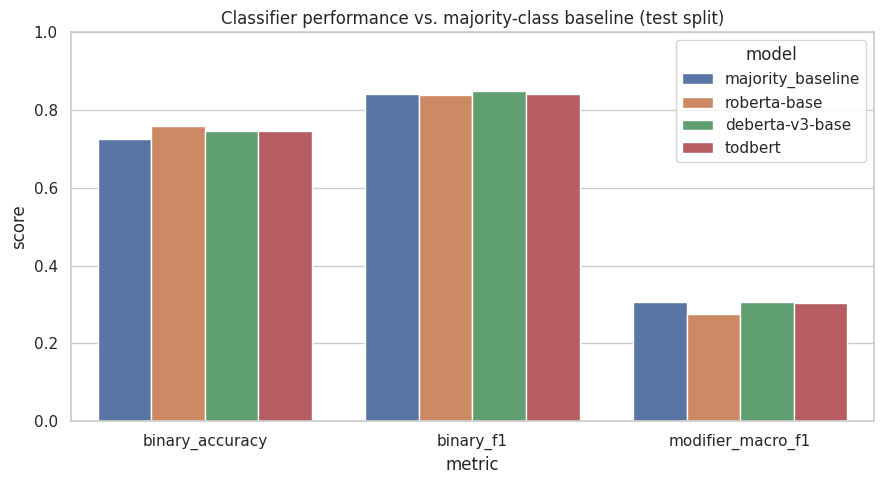

In [13]:
plot_df = summary_df.melt(
    id_vars="model",
    value_vars=["binary_accuracy", "binary_f1", "modifier_macro_f1"],
    var_name="metric", value_name="score",
)
plt.figure(figsize=(9, 5))
sns.barplot(data=plot_df, x="metric", y="score", hue="model")
plt.ylim(0, 1)
plt.title("Classifier performance vs. majority-class baseline (test split)")
plt.tight_layout()
plt.savefig(os.path.join(CONFIG["out_dir"], "classifier_comparison_bar.png"), dpi=150)
plt.show()


### 10b. Confusion matrices — binary_label, per encoder

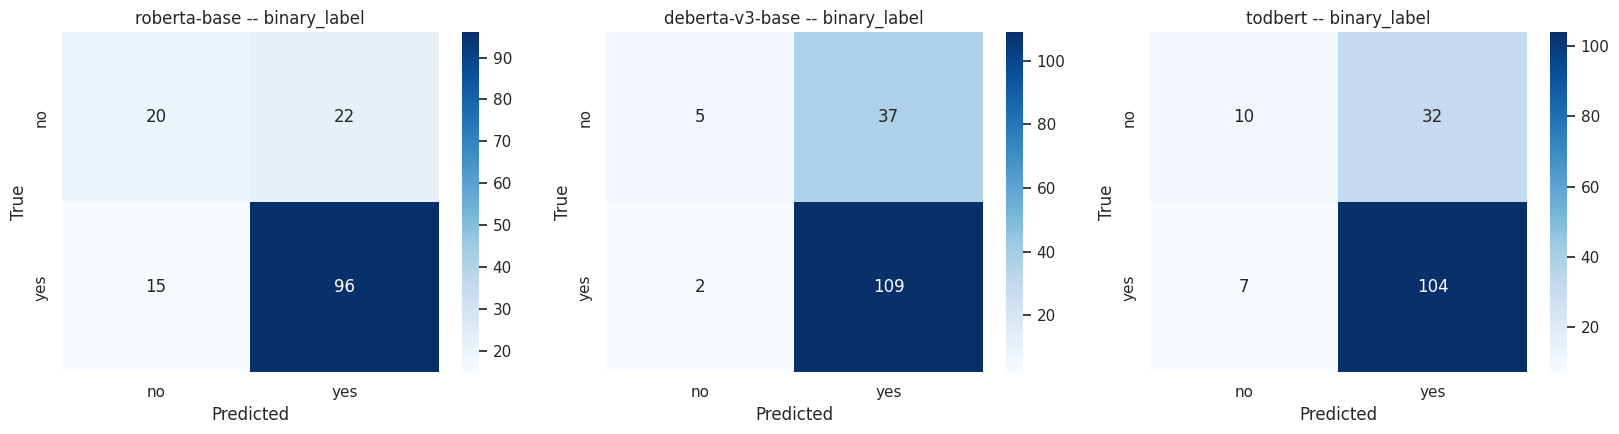

In [14]:
fig, axes = plt.subplots(1, len(results), figsize=(5.5 * len(results), 4.5))
if len(results) == 1:
    axes = [axes]
for ax, (name, r) in zip(axes, results.items()):
    cm = confusion_matrix(r["test_metrics"]["binary_true"], r["test_metrics"]["binary_pred"],
                           labels=list(range(len(CONFIG["binary_classes"]))))
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
                xticklabels=CONFIG["binary_classes"], yticklabels=CONFIG["binary_classes"], ax=ax)
    ax.set_title(f"{name} -- binary_label")
    ax.set_xlabel("Predicted"); ax.set_ylabel("True")
plt.tight_layout()
plt.savefig(os.path.join(CONFIG["out_dir"], "confusion_matrix_binary.png"), dpi=150)
plt.show()


### 10c. Confusion matrices — modifier, per encoder

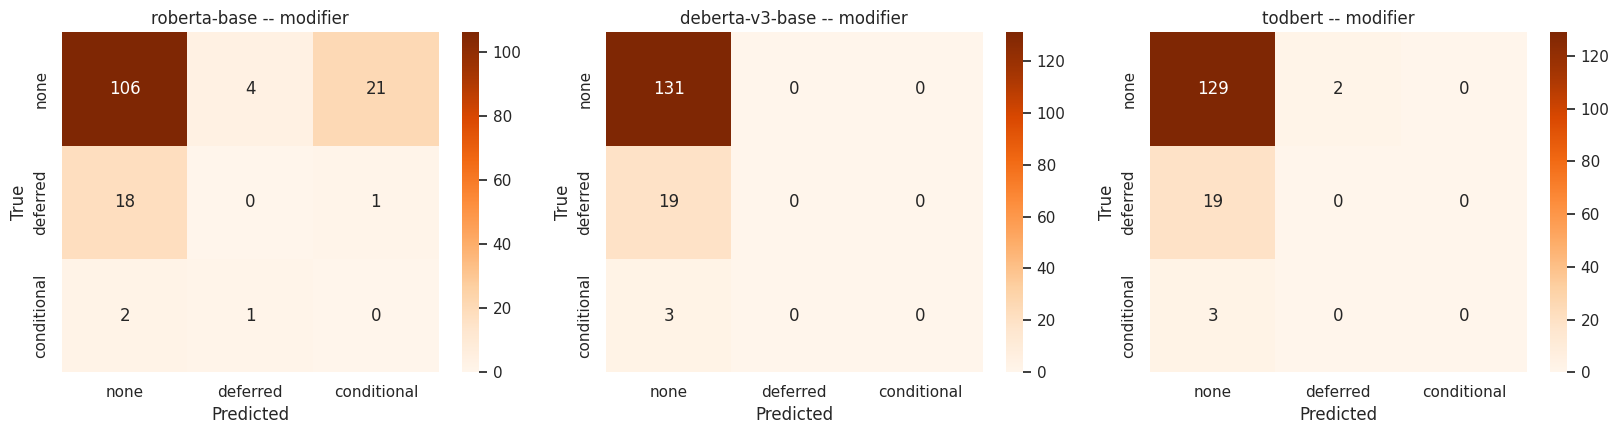

In [15]:
fig, axes = plt.subplots(1, len(results), figsize=(5.5 * len(results), 4.5))
if len(results) == 1:
    axes = [axes]
for ax, (name, r) in zip(axes, results.items()):
    cm = confusion_matrix(r["test_metrics"]["modifier_true"], r["test_metrics"]["modifier_pred"],
                           labels=list(range(len(CONFIG["modifier_classes"]))))
    sns.heatmap(cm, annot=True, fmt="d", cmap="Oranges",
                xticklabels=CONFIG["modifier_classes"], yticklabels=CONFIG["modifier_classes"], ax=ax)
    ax.set_title(f"{name} -- modifier")
    ax.set_xlabel("Predicted"); ax.set_ylabel("True")
plt.tight_layout()
plt.savefig(os.path.join(CONFIG["out_dir"], "confusion_matrix_modifier.png"), dpi=150)
plt.show()


### 10d. Training curves — val F1 per epoch, per encoder

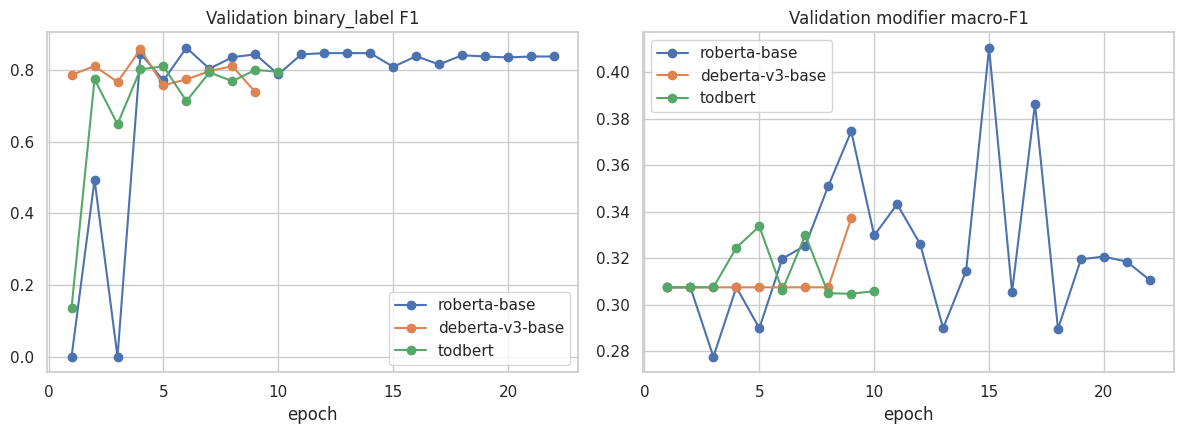

In [16]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))
for name, r in results.items():
    hist = pd.DataFrame(r["history"])
    axes[0].plot(hist["epoch"], hist["val_binary_f1"], marker="o", label=name)
    axes[1].plot(hist["epoch"], hist["val_modifier_macro_f1"], marker="o", label=name)
axes[0].set_title("Validation binary_label F1"); axes[0].set_xlabel("epoch"); axes[0].legend()
axes[1].set_title("Validation modifier macro-F1"); axes[1].set_xlabel("epoch"); axes[1].legend()
plt.tight_layout()
plt.savefig(os.path.join(CONFIG["out_dir"], "training_curves.png"), dpi=150)
plt.show()


## 10e. Classification reports (full precision/recall/F1 per class)

In [17]:
for name, r in results.items():
    _sep = "=" * 70
    print(f"\n{_sep}\n{name} -- binary_label classification report\n{_sep}")
    print(classification_report(r["test_metrics"]["binary_true"], r["test_metrics"]["binary_pred"],
                                 target_names=CONFIG["binary_classes"], zero_division=0))
    print(f"{name} -- modifier classification report")
    print(classification_report(r["test_metrics"]["modifier_true"], r["test_metrics"]["modifier_pred"],
                                 target_names=CONFIG["modifier_classes"], zero_division=0))



roberta-base -- binary_label classification report
              precision    recall  f1-score   support

          no       0.57      0.48      0.52        42
         yes       0.81      0.86      0.84       111

    accuracy                           0.76       153
   macro avg       0.69      0.67      0.68       153
weighted avg       0.75      0.76      0.75       153

roberta-base -- modifier classification report
              precision    recall  f1-score   support

        none       0.84      0.81      0.82       131
    deferred       0.00      0.00      0.00        19
 conditional       0.00      0.00      0.00         3

    accuracy                           0.69       153
   macro avg       0.28      0.27      0.27       153
weighted avg       0.72      0.69      0.71       153


deberta-v3-base -- binary_label classification report
              precision    recall  f1-score   support

          no       0.71      0.12      0.20        42
         yes       0.75      

## 11. Summary

Output files written to `CONFIG["out_dir"]`:

- `classifier_test_results.csv` — accuracy/F1 for both encoders + majority baseline, on the held-out test split.
- `checkpoints/<encoder-name>_best.pt` — best-val-F1 model weights for each encoder (state_dict, reloadable via `TwoHeadIntentClassifier` + `load_state_dict`).
- `label_distribution.png` — data diagnostics (section 2b).
- `classifier_comparison_bar.png`, `confusion_matrix_binary.png`, `confusion_matrix_modifier.png`, `training_curves.png` — result charts.

**Notes on this run's dataset:**
1. The 1017-row dataset has no partition/annotator column, so there is no partition-based stratification and no partition-specific drift check (unlike the earlier 5-annotator design) -- splitting is stratified by the `binary_label`×`modifier` combination only.
2. Blank/NaN `modifier` values were filled to `"none"`.
3. `modifier` head is computed for every row (not just `binary_label == "yes"` rows) to keep the model a clean fixed-shape two-head classifier; the "conditioned on `binary_label=yes`" framing from the task spec is instead reflected in the loss weighting (0.7x vs 1.0x) and in a dedicated conditional metric (`modifier_macro_f1_given_binary_yes`) reported in section 10 alongside the unconditional modifier metric.
